# Machine Learning Model Training and Evaluation

## **Introduction**
This script trains and evaluates three machine learning models:
- Random Forest
- Support Vector Machine (SVM)
- Logistic Regression

It performs hyperparameter tuning, model training, evaluation, and comparison.

In [298]:
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

###  **Data Loading**
- The processed dataset is loaded from a pickle file (`processed_data.pkl`).
- The dataset contains features and a target variable (`disease_type`).

In [299]:
#  Load Processed Data
file_path = "processed_data.pkl"
with open(file_path, "rb") as file:
    final_df = pickle.load(file)

In [300]:
#  Define Features and Target
X = final_df.drop(columns=['disease_type'])  # Adjust column name if necessary
y = final_df['disease_type']
X.columns

Index(['stem_sores', 'pod_health', 'growth_stage', 'rainfall', 'pod_spots',
       'season', 'stem_health', 'past_crops', 'seed_treatment',
       'seed_germination', 'halo_spots', 'lesion_size', 'temperature',
       'damaged_area', 'damage_level', 'plant_count'],
      dtype='object')

In [301]:
#  Standardize Data
scaler = StandardScaler()
X = scaler.fit_transform(X)

### **Train-Test Split**
- The dataset is split into 80% training and 20% testing.
- Stratified sampling ensures class balance in both sets.

In [302]:
#  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

### **Model Initialization**
- Three models are initialized:
  - Random Forest (default parameters)
  - SVM (default parameters)
  - Logistic Regression (default parameters)

In [303]:
#  Initialize Models
models = {
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression()  
}

### **Hyperparameter Tuning with GridSearchCV**
- A parameter grid is defined for each model.
- `GridSearchCV` is used to find the best hyperparameters.
- The best parameters are stored in `best_models`.

In [304]:
#  Hyperparameter Tuning using GridSearchCV
param_grid = {
    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
    },
    "Logistic Regression": {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs", "liblinear"],
    },
}

best_models = {}
for name, model in models.items():
    print(f"\n🔍 Tuning Hyperparameters for {name}...")
    grid_search = GridSearchCV(model, param_grid[name], cv=3, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    print(f"✅ Best Parameters for {name}: {grid_search.best_params_}")


🔍 Tuning Hyperparameters for Random Forest...
✅ Best Parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

🔍 Tuning Hyperparameters for SVM...
✅ Best Parameters for SVM: {'C': 10, 'kernel': 'rbf'}

🔍 Tuning Hyperparameters for Logistic Regression...
✅ Best Parameters for Logistic Regression: {'C': 10, 'solver': 'lbfgs'}


### **Model Training and Evaluation**
- A function `train_and_evaluate_model()` is defined to:
  - Train the model on `X_train, y_train`
  - Make predictions on `X_train` and `X_test`
  - Calculate accuracy scores
  - Generate a classification report
  - Display a confusion matrix

In [305]:
#  Define Function to Train and Evaluate Models
def train_and_evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    print(f"{name} -> Training Accuracy: {train_acc:.4f}, Testing Accuracy: {test_acc:.4f}")
    print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    
    return train_acc, test_acc

Random Forest -> Training Accuracy: 0.9985, Testing Accuracy: 0.9565
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.77      0.87      0.82        23
           2       0.96      1.00      0.98        23
           3       0.91      0.91      0.91        23
           4       1.00      0.96      0.98        23
           5       0.95      0.78      0.86        23
           6       1.00      1.00      1.00        23
           7       1.00      1.00      1.00        23
           8       1.00      1.00      1.00        23
           9       1.00      1.00      1.00        23
          10       1.00      1.00      1.00        23
          11       0.92      0.96      0.94        23
          12       0.89      0.70      0.78        23
          13       1.00      1.00      1.00        23
          14       0.82      1.00      0.90        23
          15       1.00      1.00      1.00

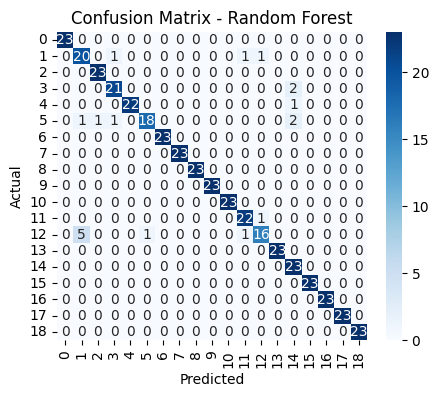

SVM -> Training Accuracy: 0.9931, Testing Accuracy: 0.9382
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.65      0.74      0.69        23
           2       1.00      1.00      1.00        23
           3       0.92      0.96      0.94        23
           4       0.95      0.91      0.93        23
           5       0.77      0.74      0.76        23
           6       1.00      1.00      1.00        23
           7       1.00      1.00      1.00        23
           8       1.00      1.00      1.00        23
           9       1.00      1.00      1.00        23
          10       1.00      1.00      1.00        23
          11       0.87      0.87      0.87        23
          12       0.80      0.70      0.74        23
          13       1.00      1.00      1.00        23
          14       0.88      0.91      0.89        23
          15       1.00      1.00      1.00        23

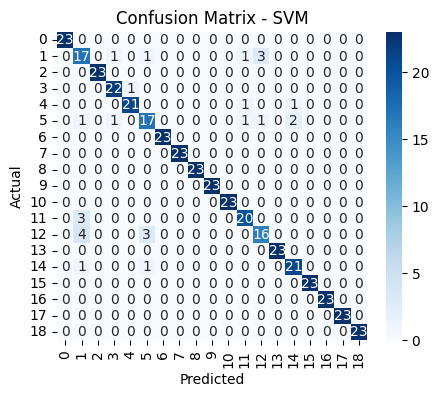

Logistic Regression -> Training Accuracy: 0.8940, Testing Accuracy: 0.8696
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.71      0.65      0.68        23
           2       0.96      1.00      0.98        23
           3       0.59      0.83      0.69        23
           4       0.47      0.30      0.37        23
           5       0.60      0.65      0.62        23
           6       1.00      1.00      1.00        23
           7       1.00      1.00      1.00        23
           8       0.96      1.00      0.98        23
           9       1.00      1.00      1.00        23
          10       1.00      1.00      1.00        23
          11       0.59      0.74      0.65        23
          12       0.93      0.61      0.74        23
          13       1.00      1.00      1.00        23
          14       0.77      0.74      0.76        23
          15       1.00      1.00    

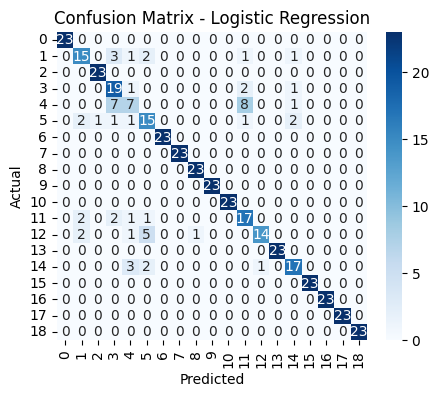

In [313]:
#  Evaluate Best Models
best_model_accuracies = {}
for name, model in best_models.items():
    train_acc, test_acc = train_and_evaluate_model(model, name)
    best_model_accuracies[name] = (train_acc, test_acc)

### **Model Comparison**
- Each best-tuned model is evaluated using `train_and_evaluate_model()`.
- Training and testing accuracies are stored in `best_model_accuracies`.

In [314]:
#  Determine Best Model Based on Test Accuracy
best_model_name = max(best_model_accuracies, key=lambda name: best_model_accuracies[name][1])
best_model = best_models[best_model_name]

### **Best Model Selection**
- The model with the highest test accuracy is selected.
- It is saved as `best_model.pkl` using `pickle`.

In [315]:
#  Save the Best Model
with open("best_model.pkl", "wb") as model_file:
    pickle.dump(best_model, model_file)

print(f"\n🏆 Best Model: {best_model_name} with Testing Accuracy: {best_model_accuracies[best_model_name][1]:.4f}")
print("✅ Best trained model saved as 'best_model.pkl'")


🏆 Best Model: Random Forest with Testing Accuracy: 0.9565
✅ Best trained model saved as 'best_model.pkl'


###  **Accuracy Comparison Plot**
- A bar chart compares training and testing accuracy across models.
- Helps visualize overfitting (high training accuracy but low testing accuracy).

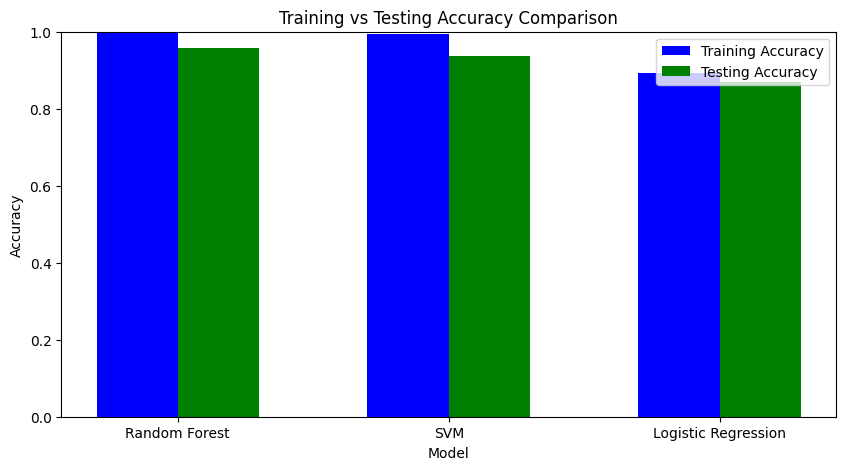

In [316]:
#  Compare Training vs Testing Accuracy
plt.figure(figsize=(10, 5))
x_labels = list(best_model_accuracies.keys())
x = np.arange(len(x_labels))
width = 0.3

train_scores = [best_model_accuracies[name][0] for name in x_labels]
test_scores = [best_model_accuracies[name][1] for name in x_labels]

plt.bar(x - width/2, train_scores, width=width, label="Training Accuracy", color='blue')
plt.bar(x + width/2, test_scores, width=width, label="Testing Accuracy", color='green')
plt.xticks(ticks=x, labels=x_labels)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy Comparison")
plt.legend()
plt.ylim(0, 1)
plt.show()